## Part A

In [112]:
import numpy as np
import matplotlib.pyplot as plt

#Creating X and Y vectors
np.random.seed(3)
X=np.random.rand(10)
X.sort()
noise=np.random.uniform(-1,1,size=len(X))
Y=0.5*X**3+0.15*X**2+0.25*X+noise

#Least Squares Method
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
#print(f"Slope: {m}, Intercept: {c}")
y_lst=m*X+c

#Polynomial fit
degree=3
co=np.polyfit(X,Y,degree)
print("Polynomial Coefficients: ", co)
poly=np.poly1d(co)
y_poly=poly(X)

Polynomial Coefficients:  [ 10.69929687 -16.97045075   8.32236738  -1.09119401]


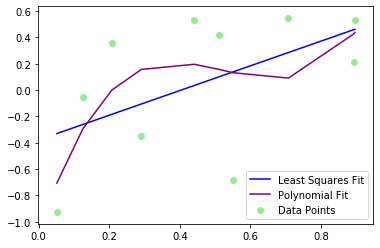

In [113]:
#Plotting
plt.figure()
plt.scatter(X,Y,label='Data Points',color='lightgreen')
plt.plot(X,y_lst,label='Least Squares Fit',color='blue')
plt.plot(X,y_poly,label='Polynomial Fit',color='purple')
plt.legend()
plt.show()

In [114]:
# MSE Least Squares
msels = np.mean((Y - y_lst)**2)
print(f'Mean Squared Error for Least Squares: {msels:.4f}')
# R-squared Least Squares
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_lst)**2)
rls = 1 - (ss_res / ss_total)
print(f'R-squared for Least Squares: {rls:.4f}')

# MSE Poly Fit
msep = np.mean((Y - y_poly)**2)
print(f'Mean Squared Error for Poly Fit: {msep:.4f}')
# R-squared Poly Fit
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_poly)**2)
rp = 1 - (ss_res / ss_total)
print(f'R-squared for Poly Fit: {rp:.4f}')

Mean Squared Error for Least Squares: 0.1913
R-squared for Least Squares: 0.2742
Mean Squared Error for Poly Fit: 0.1599
R-squared for Poly Fit: 0.3933


In [115]:
#Which Method is Better
if msels < msep:
    print('Least Squares is a better method according to MSE')
else:
    print('Polynomial Fit is a better method according to MSE')

lsdiff=1-rls
pdiff=1-rp

if lsdiff<pdiff:
    print('Least Squares is a better method according to r squared')
else:
    print('Polynomial Fit is a better method according to r squared')

Polynomial Fit is a better method according to MSE
Polynomial Fit is a better method according to r squared


## Part B

In [116]:
#Random X and Y
np.random.seed(4)
X2=np.random.rand(10)
X2.sort()
noise2=np.random.uniform(-1,1,size=len(X2))
Y=0.5*X2**3+0.15*X2**2+0.25*X2+noise2

In [117]:
#Increasing Degree
    #Over fits at degree 9
MSEO=[]
RO=[]
for i in range(1,10):
    degree=i
    co=np.polyfit(X2,Y,degree)
    poly2=np.poly1d(co)
    y=poly2(X2)
    #MSE
    MSEO.append(np.mean((Y - y)**2))
    #R Squared
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y)**2)
    r = 1 - (ss_res / ss_total)
    RO.append(r)
print(f'MSE Increasing Degree {MSEO}')
print(f'R Squared Increasing Degree {RO}')

MSE Increasing Degree [0.5215521266643168, 0.48184632047637005, 0.4634015247274115, 0.40377237220876455, 0.3557604755694223, 0.1902437571625067, 0.19018958297055438, 0.13747953883956845, 1.0097505911800856e-16]
R Squared Increasing Degree [0.02372486053426448, 0.09804876698951792, 0.13257493344846782, 0.24419265335632634, 0.33406443930296237, 0.6438893812126049, 0.6439907879830882, 0.7426568714948977, 0.9999999999999998]


In [118]:
#Decreasing Degree
    #Underfits at degree 1
MSEU=[]
RU=[]
for i in range(9,0,-1):
    degree=i
    co=np.polyfit(X2,Y,degree)
    poly2=np.poly1d(co)
    y=poly2(X2)
    #MSE
    MSEU.append(np.mean((Y - y)**2))
    #R Squared
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y)**2)
    r = 1 - (ss_res / ss_total)
    RU.append(r)
print(f'MSE Decreasing Degree {MSEU}')
print(f'R Squared Decreasing Degree {RU}')

MSE Decreasing Degree [1.0097505911800856e-16, 0.13747953883956845, 0.19018958297055438, 0.1902437571625067, 0.3557604755694223, 0.40377237220876455, 0.4634015247274115, 0.48184632047637005, 0.5215521266643168]
R Squared Decreasing Degree [0.9999999999999998, 0.7426568714948977, 0.6439907879830882, 0.6438893812126049, 0.33406443930296237, 0.24419265335632634, 0.13257493344846782, 0.09804876698951792, 0.02372486053426448]


## Part C

In [119]:
# Create Vandermonde matrix for a polynomial of degree 2
degree = 3
V = np.vander(X, N=degree+1, increasing=True)
#Wprint(V)

#Reversing the Order
polynomial=np.poly1d(co[::-1])
y_poly2=polynomial(X)

In [120]:
# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, Y)
# Solve for a (coefficients)
coe = np.linalg.solve(VT_V, VT_y)

poly2=np.poly1d(coe)
y_poly3=poly2(X)

In [121]:
# MSE Poly Fit
msep = np.mean((Y - y_poly3)**2)
print(f'Mean Squared Error: {msep:.4f}')
# R-squared Poly Fit
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_poly3)**2)
rp = 1 - (ss_res / ss_total)
print(f'R-squared: {rp:.4f}')

Mean Squared Error: 48.1569
R-squared: -89.1432
